In [57]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [58]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
# TODO: Why empyrically picked 25?
BITS_HIT = 25 

In [59]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    
    # np.log2(num_embeddings) - how many bits for specific codeword    
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

"""
Method for getting patch bits

patch_amount - total detector patch count

encoded_patch_size - encoded_width, encoded_height, num_embeddings

patch_size - patch size
"""

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(
        n_hits_total: int, 
        patch_amount: int, 
        encoded_patch_size: tuple, 
        patch_size: int
    ) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [60]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 278.68it/s]


In [61]:
batch_size = 64
beta = 0.31
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80

# input channels
channels = 1
hidden_channels = 64
latent_dim = 256
# latent_dim = 64 (on track)

# how many codebook entries
num_embeddings = 32
# num_embeddings = 32 (on track)

# logs
LOG_EVERY = 15


In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [63]:
mse = MeanSquaredError()
mse = mse.to(device)

In [64]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [65]:
event_train = events_train[:SELECTED_EVENTS][0]

In [66]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [67]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [68]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [69]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss
    # # KL_divergence
    # kl_loss = -0.5 * (
    #     1 + logvar - mu.pow(2) - logvar.exp()
    # )
    
    # kl_loss = kl_loss.mean()
    
    # return (
    #     recon_loss + beta * kl_loss,
    #     recon_loss,
    #     beta,
    #     kl_loss
    # )

In [70]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # TODO: Proove that (z_flattened - weight) ** 2 is inefficient and gives huge matrix
        # NOTE: is a matrix learnable vector for learning codebook indices
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # also it is possible to find closest codebooks by a probability distributions
        # https://arxiv.org/html/2602.02726v1

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [71]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [72]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        residual_slope: float = 0.01
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            # nn.LeakyReLU(slope),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            # nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    # def reparameterize(self, mu, logvar):
    #     return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        z_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        # z_log_mean = self.fc_mean(x_encoded)
        # z_log_var = self.fc_log_var(x_encoded)
        
        # self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        # self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        # z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [73]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.05,
    n_res_layers=2,
    res_h_dim=32
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 287.84it/s, Loss (BCE + VQ)=0.0973]


Epoch [1/80] summary:Average Loss: VQ + BCE = 0.1950,  Average loss: BCE = 0.0743 MSE = 0.009302184083990415 avg_perplexity = 2.9897667025800927
Average validation set BCE loss: 0.058673710227012635
Before compression (Training)
Shape: (13, 8, 8)


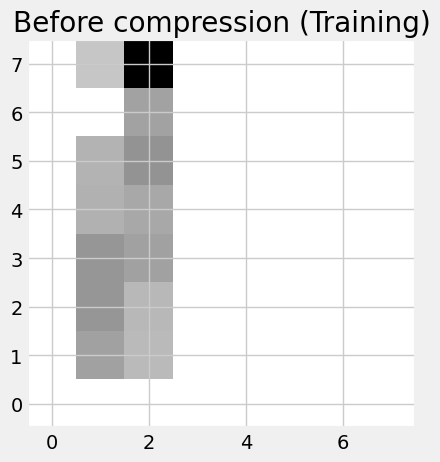

After compression (Training)
Shape: (1, 8, 8)


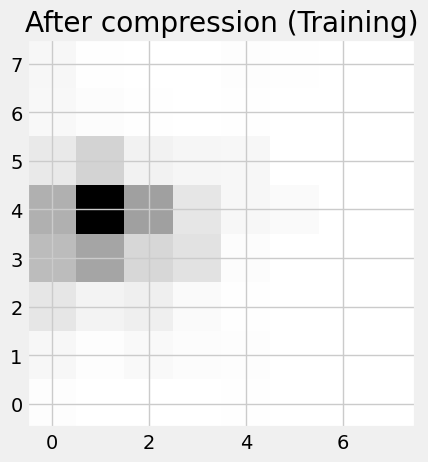

Before compression (Validation)
Shape: (64, 8, 8)


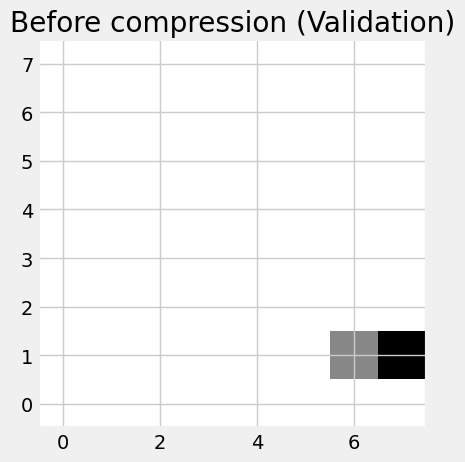

After compression (Validation)
Shape: (1, 8, 8)


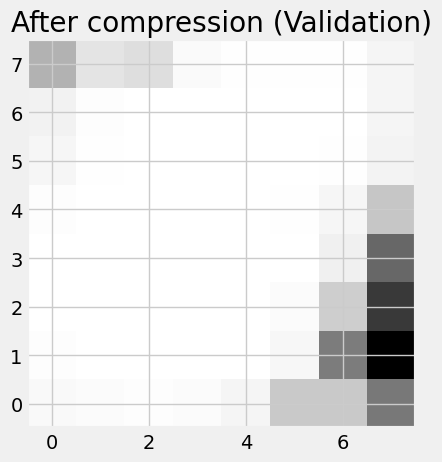

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 303.50it/s, Loss (BCE + VQ)=0.0486]


Epoch [2/80] summary:Average Loss: VQ + BCE = 0.0670,  Average loss: BCE = 0.0539 MSE = 0.005794915506363514 avg_perplexity = 4.941331205655582
Average validation set BCE loss: 0.0506196416914463


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 305.06it/s, Loss (BCE + VQ)=0.0379]


Epoch [3/80] summary:Average Loss: VQ + BCE = 0.0591,  Average loss: BCE = 0.0488 MSE = 0.004989544845808615 avg_perplexity = 5.677178263065204
Average validation set BCE loss: 0.04697643846273422


...

Epoch [14/80] summary:Average Loss: VQ + BCE = 0.0441,  Average loss: BCE = 0.0389 MSE = 0.003414594921653145 avg_perplexity = 7.160447923382323
Average validation set BCE loss: 0.04044085599482059


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 401.88it/s, Loss (BCE + VQ)=0.0335]


Epoch [15/80] summary:Average Loss: VQ + BCE = 0.0433,  Average loss: BCE = 0.0384 MSE = 0.0033404467394575477 avg_perplexity = 7.754385495305661
Average validation set BCE loss: 0.039594361111521724


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 399.51it/s, Loss (BCE + VQ)=0.0359]


Epoch [16/80] summary:Average Loss: VQ + BCE = 0.0431,  Average loss: BCE = 0.0382 MSE = 0.003304042284208439 avg_perplexity = 7.8970118383666374
Average validation set BCE loss: 0.03910159170627594
Before compression (Training)
Shape: (13, 8, 8)


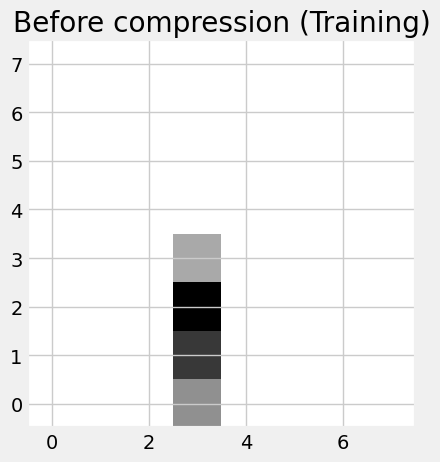

After compression (Training)
Shape: (1, 8, 8)


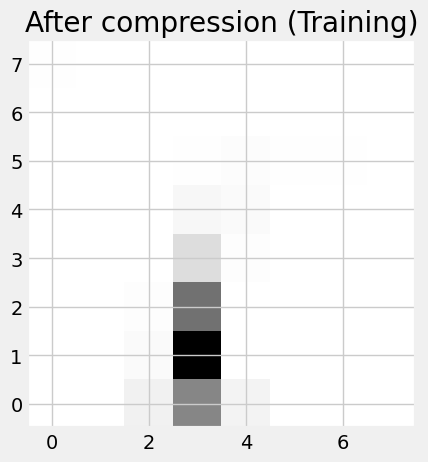

Before compression (Validation)
Shape: (64, 8, 8)


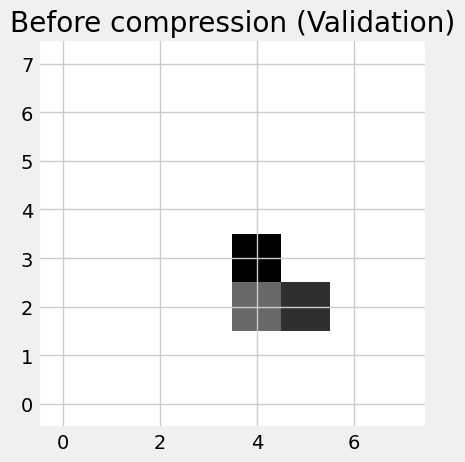

After compression (Validation)
Shape: (1, 8, 8)


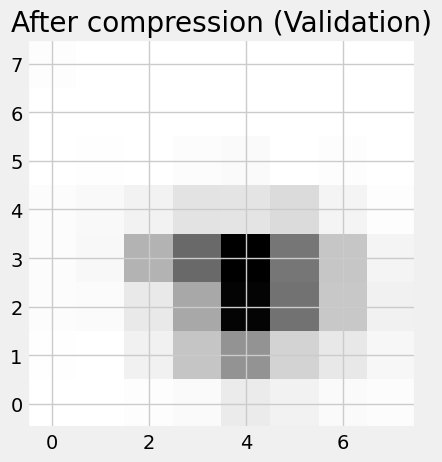

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 393.72it/s, Loss (BCE + VQ)=0.0649]


Epoch [17/80] summary:Average Loss: VQ + BCE = 0.0427,  Average loss: BCE = 0.0380 MSE = 0.003258579866328843 avg_perplexity = 7.933806750043552
Average validation set BCE loss: 0.039271451458334924


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 400.16it/s, Loss (BCE + VQ)=0.0464]


Epoch [18/80] summary:Average Loss: VQ + BCE = 0.0420,  Average loss: BCE = 0.0376 MSE = 0.003187544238472816 avg_perplexity = 8.378237175582042
Average validation set BCE loss: 0.03865366913378239


...

Epoch [29/80] summary:Average Loss: VQ + BCE = 0.0399,  Average loss: BCE = 0.0358 MSE = 0.0028287341242571873 avg_perplexity = 8.685555419730182
Average validation set BCE loss: 0.03765060119330883


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 404.72it/s, Loss (BCE + VQ)=0.0435]


Epoch [30/80] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0357 MSE = 0.0028252177421312463 avg_perplexity = 8.650383623401124
Average validation set BCE loss: 0.03763243786990642


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 398.75it/s, Loss (BCE + VQ)=0.0349]


Epoch [31/80] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0355 MSE = 0.0027873335159313514 avg_perplexity = 8.669590679245378
Average validation set BCE loss: 0.03733327642083168
Before compression (Training)
Shape: (13, 8, 8)


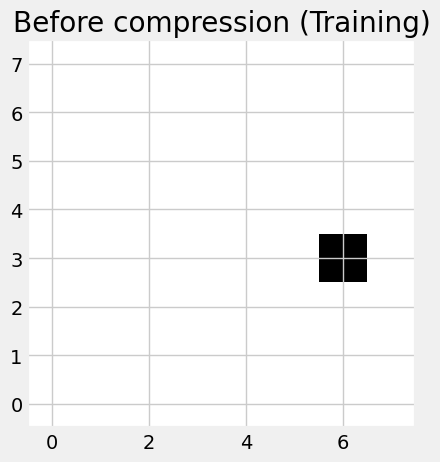

After compression (Training)
Shape: (1, 8, 8)


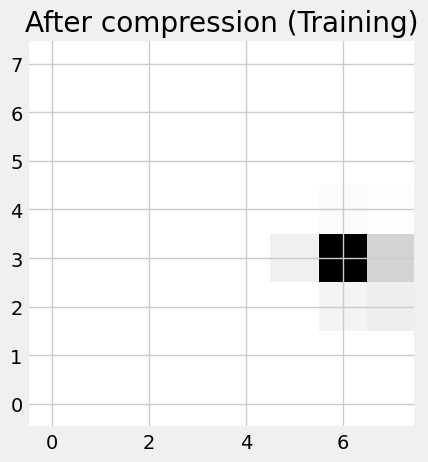

Before compression (Validation)
Shape: (64, 8, 8)


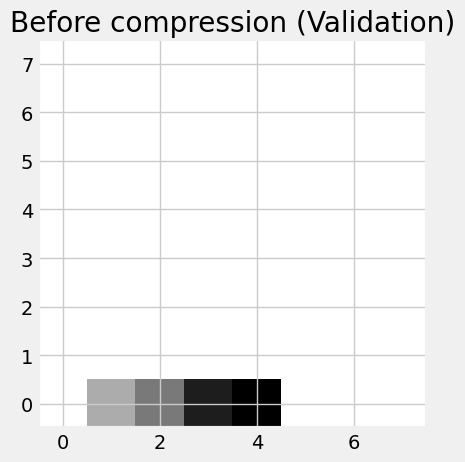

After compression (Validation)
Shape: (1, 8, 8)


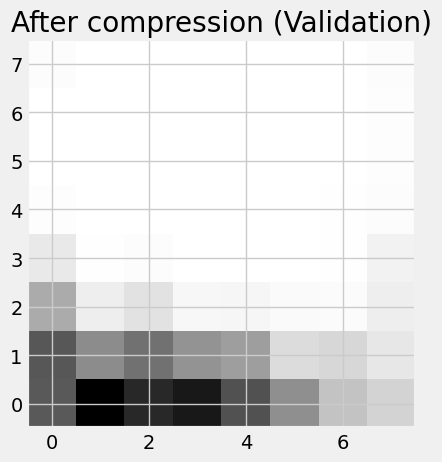

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 397.96it/s, Loss (BCE + VQ)=0.049] 


Epoch [32/80] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0355 MSE = 0.002771703891418687 avg_perplexity = 8.670667581222764
Average validation set BCE loss: 0.037488659918308256


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 404.98it/s, Loss (BCE + VQ)=0.0348]


Epoch [33/80] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0356 MSE = 0.002820817994693266 avg_perplexity = 8.665067008991338
Average validation set BCE loss: 0.03760899841785431


...

Epoch [44/80] summary:Average Loss: VQ + BCE = 0.0388,  Average loss: BCE = 0.0348 MSE = 0.002631053301019023 avg_perplexity = 8.616896188438837
Average validation set BCE loss: 0.037214943543076515


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 394.29it/s, Loss (BCE + VQ)=0.0239]


Epoch [45/80] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0346 MSE = 0.0025962262923932217 avg_perplexity = 8.633385248519668
Average validation set BCE loss: 0.03709620155394077


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 394.37it/s, Loss (BCE + VQ)=0.0398]


Epoch [46/80] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0346 MSE = 0.0025889956563168283 avg_perplexity = 8.651556451116974
Average validation set BCE loss: 0.037611804828047754
Before compression (Training)
Shape: (13, 8, 8)


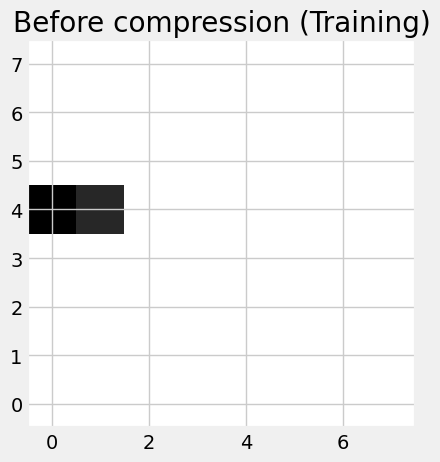

After compression (Training)
Shape: (1, 8, 8)


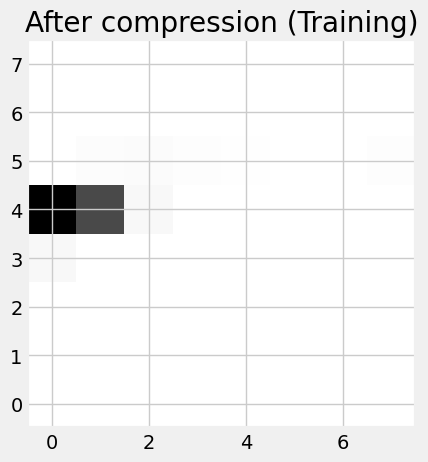

Before compression (Validation)
Shape: (64, 8, 8)


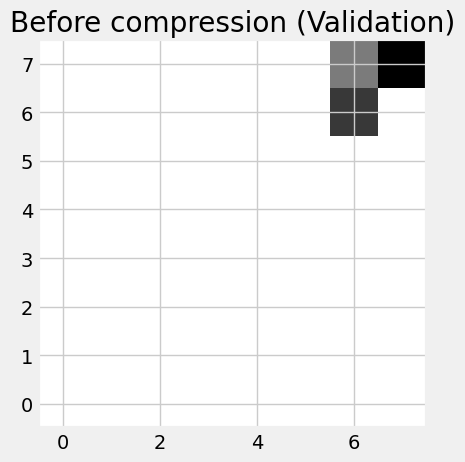

After compression (Validation)
Shape: (1, 8, 8)


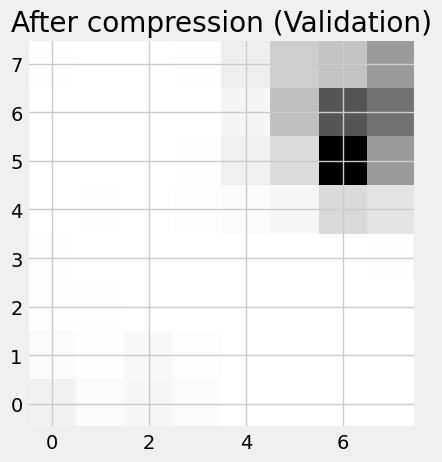

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 401.46it/s, Loss (BCE + VQ)=0.0378]


Epoch [47/80] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0346 MSE = 0.0025999746215178737 avg_perplexity = 8.64241458902407
Average validation set BCE loss: 0.037299768924713136


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 398.41it/s, Loss (BCE + VQ)=0.0302]


Epoch [48/80] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0346 MSE = 0.002605013227576961 avg_perplexity = 8.621227585490624
Average validation set BCE loss: 0.0375298547744751


...

Epoch [59/80] summary:Average Loss: VQ + BCE = 0.0380,  Average loss: BCE = 0.0340 MSE = 0.0024743256189546843 avg_perplexity = 8.61492316567119
Average validation set BCE loss: 0.03745581135153771


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 410.27it/s, Loss (BCE + VQ)=0.0661]


Epoch [60/80] summary:Average Loss: VQ + BCE = 0.0380,  Average loss: BCE = 0.0340 MSE = 0.002469769005088051 avg_perplexity = 8.620614327378009
Average validation set BCE loss: 0.03733867950737477


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 396.14it/s, Loss (BCE + VQ)=0.0308]


Epoch [61/80] summary:Average Loss: VQ + BCE = 0.0381,  Average loss: BCE = 0.0342 MSE = 0.002505993467039574 avg_perplexity = 8.619741037263344
Average validation set BCE loss: 0.03776181779801845
Before compression (Training)
Shape: (13, 8, 8)


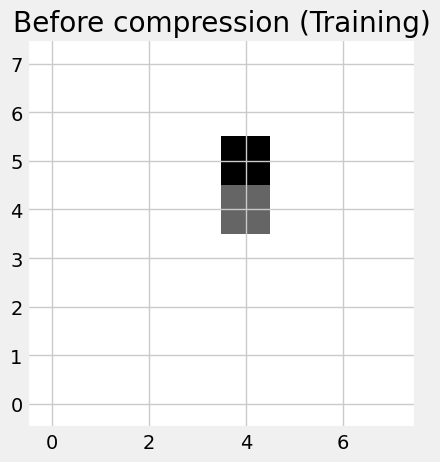

After compression (Training)
Shape: (1, 8, 8)


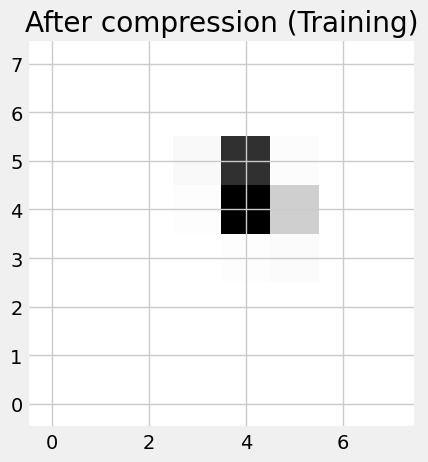

Before compression (Validation)
Shape: (64, 8, 8)


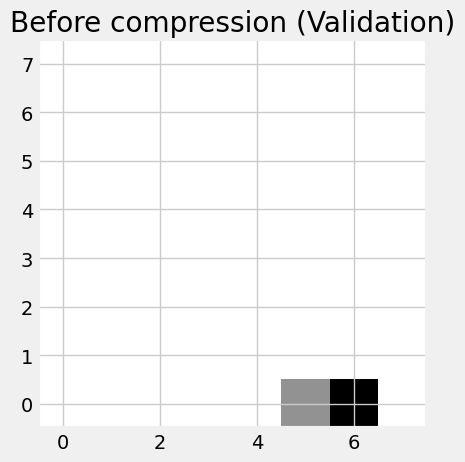

After compression (Validation)
Shape: (1, 8, 8)


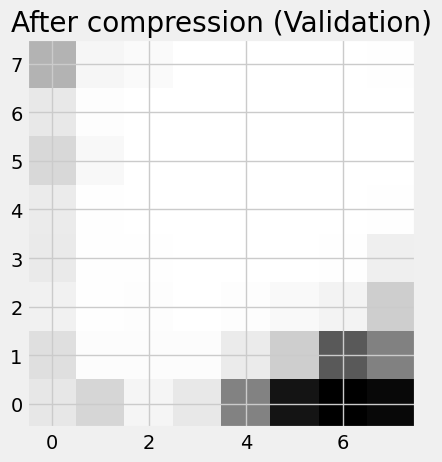

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 386.84it/s, Loss (BCE + VQ)=0.0349]


Epoch [62/80] summary:Average Loss: VQ + BCE = 0.0377,  Average loss: BCE = 0.0339 MSE = 0.002440460408270247 avg_perplexity = 8.613080482387064
Average validation set BCE loss: 0.03749164901673794


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 398.90it/s, Loss (BCE + VQ)=0.0262]


Epoch [63/80] summary:Average Loss: VQ + BCE = 0.0376,  Average loss: BCE = 0.0337 MSE = 0.0023992021858280327 avg_perplexity = 8.62697883347171
Average validation set BCE loss: 0.037709107622504234


...

Epoch [74/80] summary:Average Loss: VQ + BCE = 0.0371,  Average loss: BCE = 0.0334 MSE = 0.0023088988206868793 avg_perplexity = 8.852265310047859
Average validation set BCE loss: 0.03698985449969769


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 401.09it/s, Loss (BCE + VQ)=0.025] 


Epoch [75/80] summary:Average Loss: VQ + BCE = 0.0369,  Average loss: BCE = 0.0332 MSE = 0.002288731593105137 avg_perplexity = 8.85660364639819
Average validation set BCE loss: 0.03677691265940666


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 402.93it/s, Loss (BCE + VQ)=0.0441]


Epoch [76/80] summary:Average Loss: VQ + BCE = 0.0369,  Average loss: BCE = 0.0333 MSE = 0.002272576936076035 avg_perplexity = 8.849941967719763
Average validation set BCE loss: 0.03708075821399689
Before compression (Training)
Shape: (13, 8, 8)


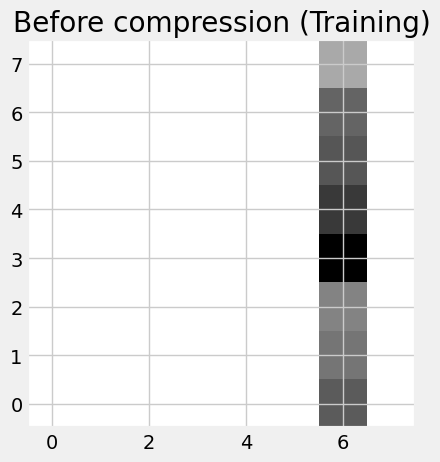

After compression (Training)
Shape: (1, 8, 8)


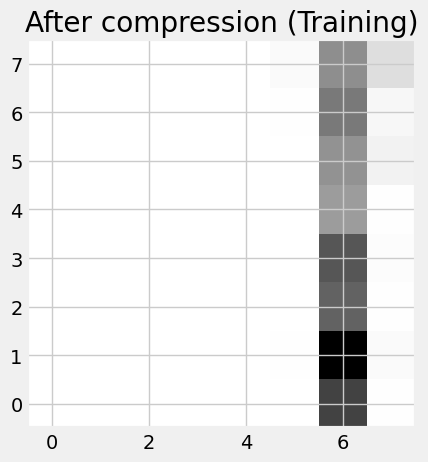

Before compression (Validation)
Shape: (64, 8, 8)


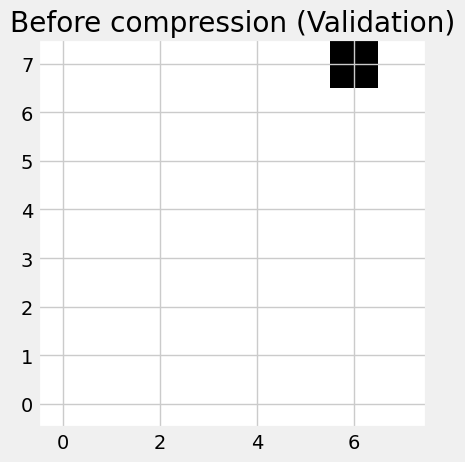

After compression (Validation)
Shape: (1, 8, 8)


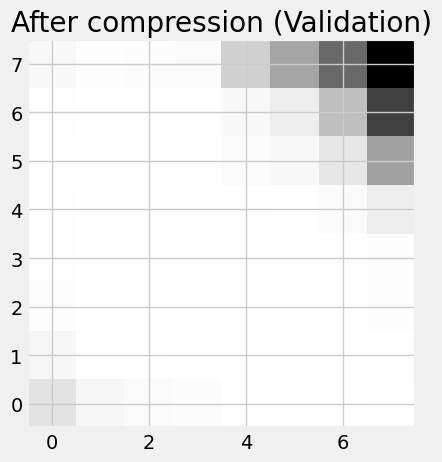

----------------------------------------
Patch = 5 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 401.79it/s, Loss (BCE + VQ)=0.0259]


Epoch [77/80] summary:Average Loss: VQ + BCE = 0.0369,  Average loss: BCE = 0.0332 MSE = 0.002269574959912155 avg_perplexity = 8.872719359757314
Average validation set BCE loss: 0.03711624287068844


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 405.71it/s, Loss (BCE + VQ)=0.0336]


Epoch [78/80] summary:Average Loss: VQ + BCE = 0.0368,  Average loss: BCE = 0.0332 MSE = 0.0022704145179630896 avg_perplexity = 8.867353820321547
Average validation set BCE loss: 0.0367362117767334


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 406.02it/s, Loss (BCE + VQ)=0.0343]


Epoch [79/80] summary:Average Loss: VQ + BCE = 0.0367,  Average loss: BCE = 0.0331 MSE = 0.0022303962456436837 avg_perplexity = 8.855068868129097
Average validation set BCE loss: 0.0369326364248991


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 393.37it/s, Loss (BCE + VQ)=0.0417]


Epoch [80/80] summary:Average Loss: VQ + BCE = 0.0365,  Average loss: BCE = 0.0329 MSE = 0.002194168170137172 avg_perplexity = 8.861838762484604
Average validation set BCE loss: 0.03702279470860958
Saving trained model VQ-VAE


In [74]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25
plot_idx = 0


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
        
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
            # result = _get_compression_ratio_vae(
            #     total_hit_amount, 
            #     patch_amount,
            #     zhidden_channels * 2
            # )
        
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = _tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = _tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(_tensor_to_numpy(codebook_train))
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch_val, 
                        codebook_val, 
                        z_q_val, 
                        perplexity_val,
                        _
                    ) = model(patch_val)
                    
                    if len(patches_pairs_val) < plot_val_patches_limit:
                        patches_pairs_val.append(
                            (
                                patch_val, 
                                z_q_val, 
                                recon_patch_val, 
                                codebook_val
                            )
                        )
                
                if plot_idx < len(patches_pairs_val):
                    (
                        patch_val, 
                        z_q_val, 
                        recon_patch_val, 
                        codebook_val
                    ) = patches_pairs_val[plot_idx]
                    
                    print("Before compression (Validation)")                    
                    patch_val_ts_val = _tensor_to_numpy(
                        patch_val.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts_val.shape}")            
                    plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                    
                    patches_before_val.append(patch_val_ts_val[0])
                    
                    recon_patch_np_val = _tensor_to_numpy(
                        recon_patch_val[0]
                    )
                    print("After compression (Validation)")
                    print(f"Shape: {recon_patch_np_val.shape}")
                    
                    plot_patch(recon_patch_np_val[0], "After compression (Validation)")
                
                    patches_after_val.append(recon_patch_np_val[0])  
                    encodings_val_np = _tensor_to_numpy(codebook_val)
                    patches_encodings_val.append(encodings_val_np) 
                    
                    width_val, height_val = z_q_val[0][0].shape
                    c_width, c_height = codebook_val.shape
                    
                    print("----------------------------------------")
                    print(f"Patch = {plot_idx} compression results")
                    print("----------------------------------------")
                    print(
                        f"Patch encoder output dimensions:"
                        f"(w x h) = ({width_val}) x ({height_val})"
                    )
                    
                    compression_ratio = _get_compression_ratio(
                        n_hits_total=total_hit_amount,
                        patch_amount=patch_amount,
                        encoded_patch_size=(width_val, height_val, num_embeddings),
                        patch_size=PATCH_SIZE
                    )
                    total_bits = _get_total_hit_bits(total_hit_amount)
                    encoded_patch_bits = _get_encoded_patch_bits(
                        (width_val, height_val, num_embeddings), 
                        PATCH_SIZE
                    )
                    
                    print(f"Compression ratio = {compression_ratio}")
                    print(f"total_hit_amount = {total_hit_amount}")
                    print(f"total_hit_bits = {total_bits}")
                    print(f"patch_amount = {patch_amount}")
                    print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                    print(f"num_embeddings = {num_embeddings}")
                    print(f"Codebook dimensions: {c_width} x {c_height}")
                    print("----------------------------------------")
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [75]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [76]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits
total_bits = _get_total_hit_bits(total_hit_amount)


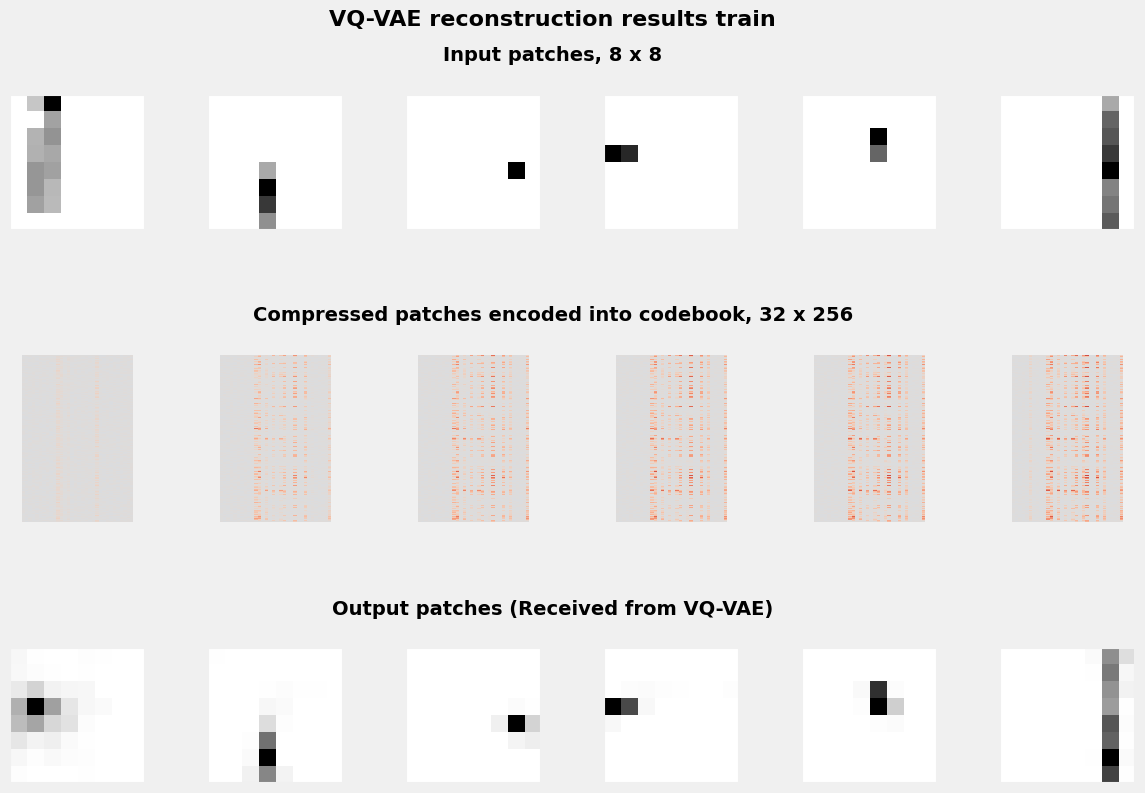

In [77]:
def plot_patches(patch_rows: list[tuple], title: str) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    fig = plt.figure(figsize=(2.2 * cols, 8.5))

    gs = GridSpec(
        rows,
        cols,
        figure=fig,
        height_ratios=[1.2, 1.5, 1.2],
        wspace=0.25,
        hspace=0.85
    )

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )
    
    global_abs_max = max(
        p.detach().cpu().abs().max().item()
        if hasattr(p, "detach") else abs(p).max()
        for p in patch_rows[1][0]
    )

    for i in range(rows):
        patch_row, patch_row_title = patch_rows[i]

        # Row title aligned above each row
        row_top = gs[i, :].get_position(fig).y1
        fig.text(
            0.5,
            row_top + 0.035,
            patch_row_title,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )

        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])

            patch = patch_row[j]

            # Keep your current row-1 transpose logic
            if i == 1:
                patch = patch.T

                im = ax.imshow(
                    patch,
                    cmap="coolwarm",
                    origin="lower",
                    aspect="auto",
                    interpolation="nearest",
                    vmin=-global_abs_max,
                    vmax=global_abs_max
                )

                ax.set_box_aspect(1.5)


            else:
                im = ax.imshow(
                    patch,
                    cmap="gist_yarg",
                    origin="lower",
                    aspect="equal"
                )

                # Square input/output patches
                ax.set_box_aspect(1.0)

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

    plt.show()
        
        
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results train")

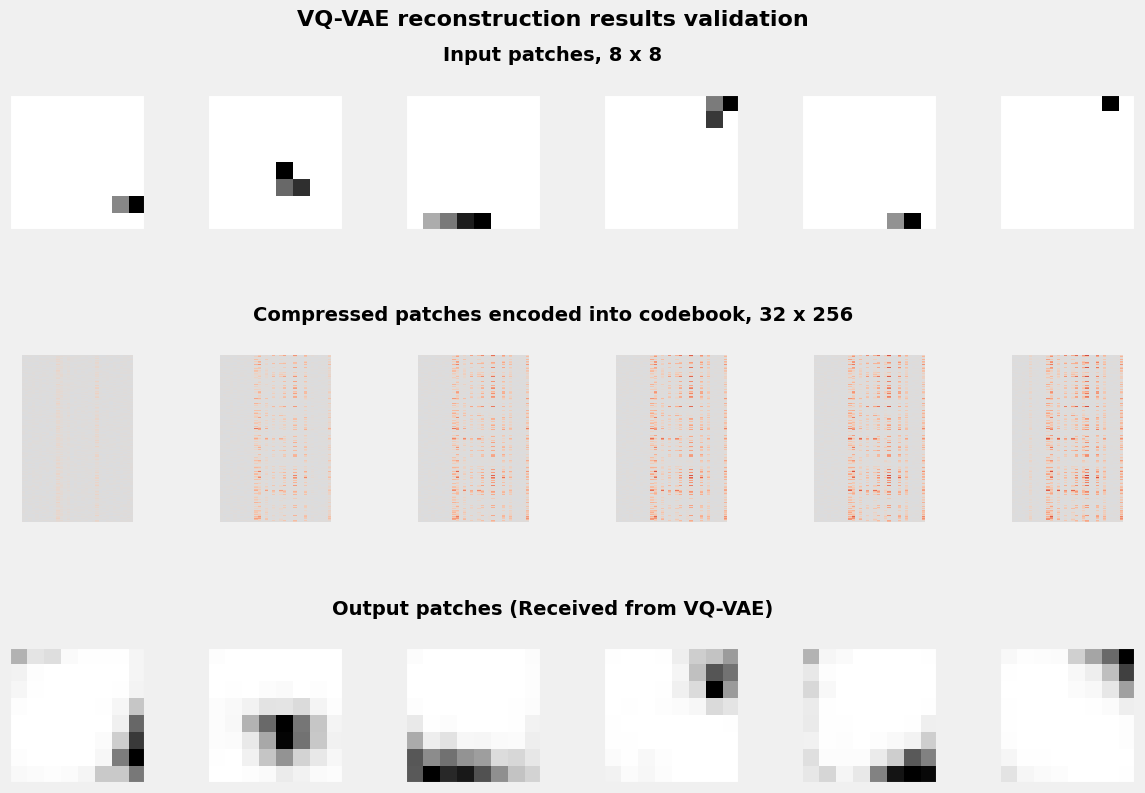

In [78]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results validation")

In [79]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.021318066865205765
encoder.1.weight 0.0037135377060621977
encoder.1.bias 0.006221594754606485
encoder.3.weight 0.03581874072551727
encoder.4.weight 0.0025823619216680527
encoder.4.bias 0.0029602358117699623
encoder.6.weight 0.02467110939323902
encoder.7.weight 0.002149025211110711
encoder.7.bias 0.004264500457793474
encoder.8.stack.0.res_block.1.weight 0.011775759048759937
encoder.8.stack.0.res_block.3.weight 0.01232893392443657
encoder.8.stack.1.res_block.1.weight 0.01540370099246502
encoder.8.stack.1.res_block.3.weight 0.007427240256220102
vq_layer.embedding.weight 0.00033442280255258083
decoder.0.weight 0.008949341252446175
decoder.1.weight 0.003588683670386672
decoder.1.bias 0.0023377954494208097
decoder.2.stack.0.res_block.1.weight 0.008047525770962238
decoder.2.stack.0.res_block.3.weight 0.010671470314264297
decoder.2.stack.1.res_block.1.weight 0.01266619935631752
decoder.2.stack.1.res_block.3.weight 0.010867170058190823
decoder.3.weight

VQ VAE, BCE encoder average loss values over epochs


/tmp/ipykernel_441996/831797292.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


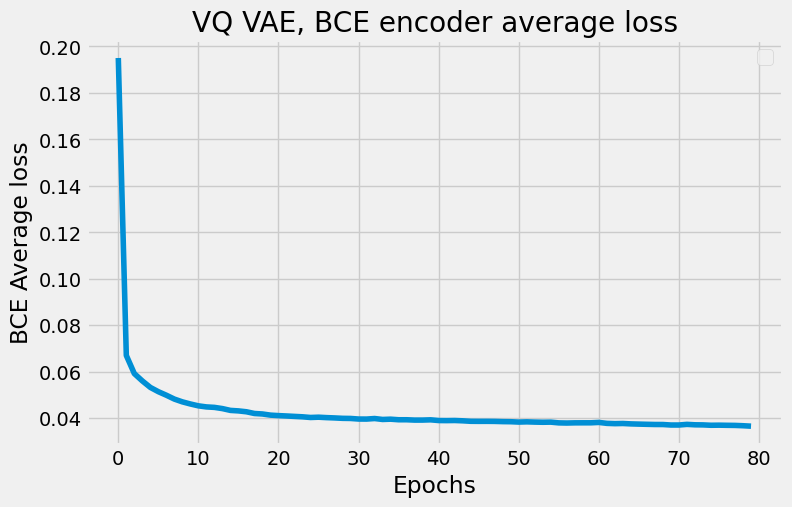

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [80]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [81]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(_tensor_to_numpy(codebook_test))
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 25), average BCE loss = 0.39097
Based on test set (size = 25), average codebook perplexity = 8.86222/32
Saved VQ-VAE test results


In [82]:
len(patches_before_test)

6

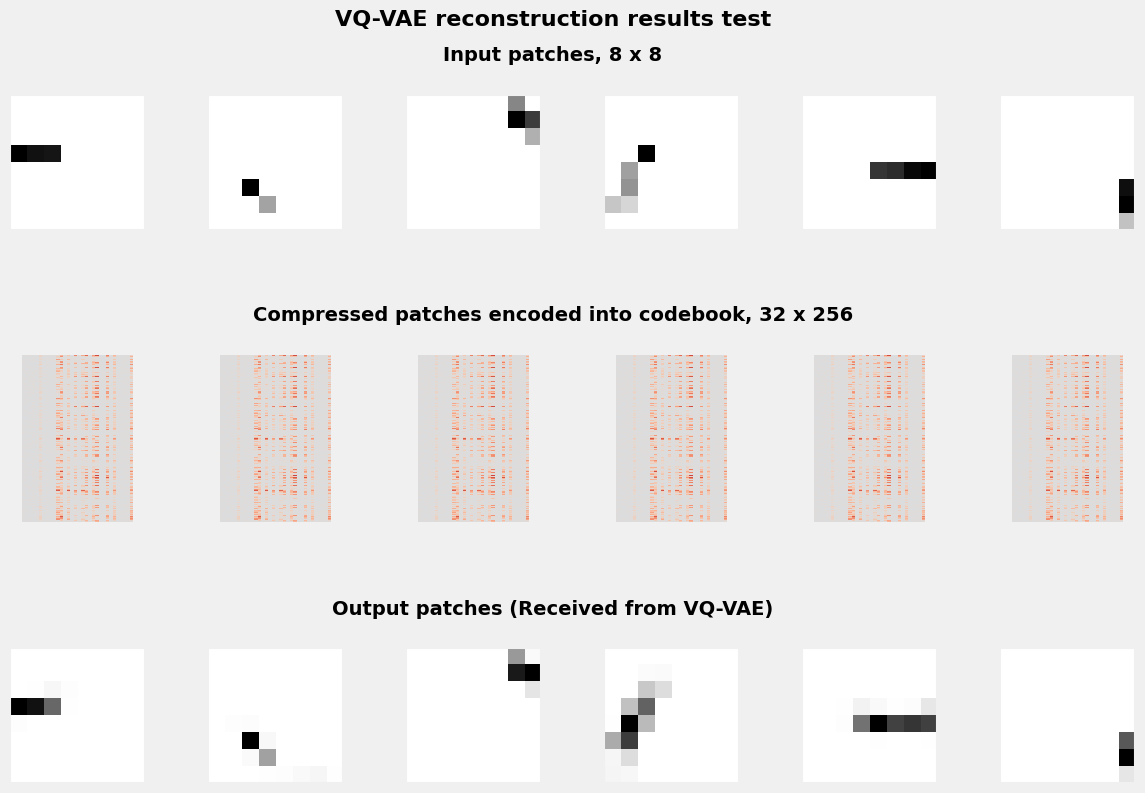

In [83]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results test")

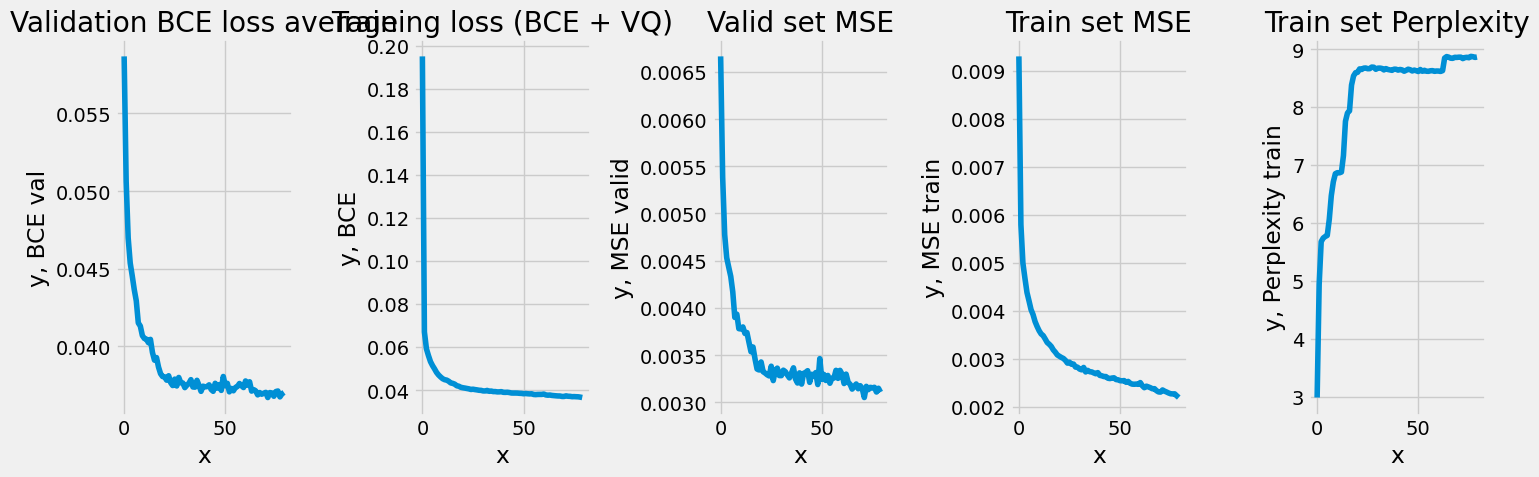

In [84]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 5))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Results:
<!-- * Perplexity shows that per patch about 10 from 16 codebook entries are used
* Reconstruction quality is about average. Representations with validation and test tests
look marginally similar to the input images
* Compression ratio shows that input image successfully was scaled about 3 times (~2.8).
* 1 encoded patch has 27 bits, while 1 encoded patch in VAE has 128 bits. 
* beta = 4e-3 (commitment cost) given better results. Beta needs to be very small and once smaller, gives better results. Based on official VQ-VAE research paper, image compression, requires beta to in the inverval [0.1, 2.0] -->
* Codebook entries from 16 vectors (rows), only approximately 8 codebook entries are used based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction
* Validation set properly works with higher beta coeficient
* Codebook plots describe codebook variation, whether certain weights are mostly zero and are codebook usage is not sparse